In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

Распределение классов:
0    5000
1    5000
Name: class, dtype: int64

Всего точек: 10000

Первые 10 строк:
    x  y  class
0   1  1      0
1   2  1      0
2   3  1      1
3   4  1      1
4   5  1      0
5   6  1      0
6   7  1      1
7   8  1      1
8   9  1      0
9  10  1      0


<Axes: xlabel='x', ylabel='y'>

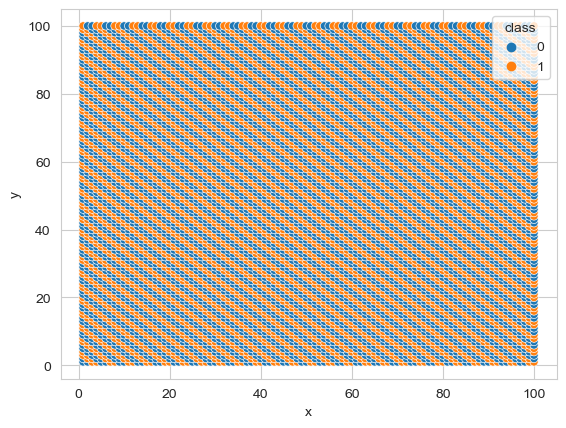

In [6]:
import numpy as np
import pandas as pd

def generate_diagonal_stripes(n=10, stripe_width=2):
    """
    Генератор датасета с диагональными полосами.
    Класс определяется по значению (x + y) mod (2 * stripe_width).

    Возвращает DataFrame с колонками: x, y, class
    """
    # Генерируем сетку 10x10
    xs = np.arange(1, n+1)
    ys = np.arange(1, n+1)
    X, Y = np.meshgrid(xs, ys)

    # Значение: сумма координат
    Z = X + Y

    # Класс: 0 или 1 в зависимости от "фазы" суммы
    # Полосы: 0,1,2,3,4,5,6,7,8,9 по модулю
    # Разбиваем на два класса: чётные полосы — класс 0, нечётные — класс 1
    classes = (Z % (2 * stripe_width)) < stripe_width

    # Собираем в DataFrame
    df = pd.DataFrame({
        'x': X.flatten(),
        'y': Y.flatten(),
        'class': classes.flatten().astype(int)
    })

    return df

# Пример использования
np.random.seed(42)
df = generate_diagonal_stripes(n=100, stripe_width=2)

# Проверка сбалансированности
print("Распределение классов:")
print(df['class'].value_counts())
print(f"\nВсего точек: {len(df)}")

# Показать первые несколько строк
print("\nПервые 10 строк:")
print(df.head(10))

sns.scatterplot(data = df, x = 'x', y = 'y', hue='class')

In [7]:
X = df.drop(columns = ['class'])
y = df['class']

score_train_list = []
score_test_list = []

for seed in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
accuracy_train = round(np.array(score_train_list).mean(), 4)
accuracy_test = round(np.array(score_test_list).mean(), 4)

print('accuracy_train =', accuracy_train)
print('accuracy_test =', accuracy_test)

accuracy_train = 0.7902
accuracy_test = 0.4339


In [8]:
X = df.drop(columns = ['class'])
y = df['class']

score_train_list = []
score_test_list = []

for seed in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    model = KNeighborsClassifier(metric='manhattan')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
accuracy_train = round(np.array(score_train_list).mean(), 4)
accuracy_test = round(np.array(score_test_list).mean(), 4)

print('accuracy_train =', accuracy_train)
print('accuracy_test =', accuracy_test)

accuracy_train = 0.6545
accuracy_test = 0.2192


In [33]:
import numpy as np
import pandas as pd

# Сетка 10x10
x1 = np.repeat(np.arange(1, 21), 20)
x2 = np.tile(np.arange(1, 21), 20)

df = pd.DataFrame({'x1': x1, 'x2': x2})

# Центр и радиус ромба (L1-шара)
center_x, center_y = 10, 10
radius = 4.2  # подбираем так, чтобы классы были примерно сбалансированы

# Вычисляем L1-расстояние до центра
l1_dist = np.abs(df['x1'] - center_x) + np.abs(df['x2'] - center_y)

# Метка: внутри ромба — 0, снаружи — 1
df['y'] = (l1_dist > radius).astype(int)

print(df['y'].value_counts())
df

1    359
0     41
Name: y, dtype: int64


,x1,x2,y
0,1,1,1
1,1,2,1
2,1,3,1
3,1,4,1
4,1,5,1
...,...,...,...
395,20,16,1
396,20,17,1
397,20,18,1
398,20,19,1


In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

X = df[['x1', 'x2']].values
y = df['y'].values

k = 5  # можно попробовать разные k

knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=5, scoring='accuracy')
cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=5, scoring='accuracy')

print('L2 (Euclidean) CV accuracy:', cv_scores_l2.mean(), '±', cv_scores_l2.std())
print('L1 (Manhattan) CV accuracy:', cv_scores_l1.mean(), '±', cv_scores_l1.std())


L2 (Euclidean) CV accuracy: 0.9049999999999999 ± 0.039210967853395284
L1 (Manhattan) CV accuracy: 0.8949999999999999 ± 0.03588175023601831


In [35]:
df

,x1,x2,y
0,1,1,1
1,1,2,1
2,1,3,1
3,1,4,1
4,1,5,1
...,...,...,...
395,20,16,1
396,20,17,1
397,20,18,1
398,20,19,1


1    220
0    180
Name: y, dtype: int64


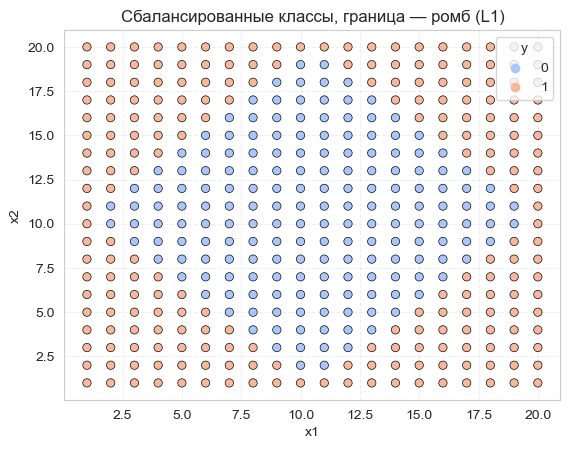

L2 (Euclidean) CV accuracy: 0.7675 ± 0.0232
L1 (Manhattan) CV accuracy: 0.7675 ± 0.0292


In [53]:
import numpy as np
import pandas as pd

# Сетка 20x20
x1 = np.repeat(np.arange(1, 21), 20)
x2 = np.tile(np.arange(1, 21), 20)

df = pd.DataFrame({'x1': x1, 'x2': x2})

# Центр и радиус ромба (L1-шара)
center_x, center_y = 10.5, 10.5
radius = 9  # подбираем так, чтобы классы были примерно сбалансированы

# Вычисляем L1-расстояние до центра
l1_dist = np.abs(df['x1'] - center_x) + np.abs(df['x2'] - center_y)

# Метка: внутри ромба — 0, снаружи — 1
df['y'] = (l1_dist > radius).astype(int)

print(df['y'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='coolwarm', edgecolor='k')

plt.grid(True, linestyle='--', alpha=0.3)
plt.title('Сбалансированные классы, граница — ромб (L1)')
plt.show()

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

X = df[['x1', 'x2']].values
y = df['y'].values

k = 5  # можно попробовать разные k

knn_l2 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_l1 = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=5, scoring='accuracy')
cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=5, scoring='accuracy')

print('L2 (Euclidean) CV accuracy:', round(cv_scores_l2.mean(),4), '±', round(cv_scores_l2.std(),4))
print('L1 (Manhattan) CV accuracy:', round(cv_scores_l1.mean(),4), '±', round(cv_scores_l1.std(),4))

0    58
1    42
Name: y, dtype: int64


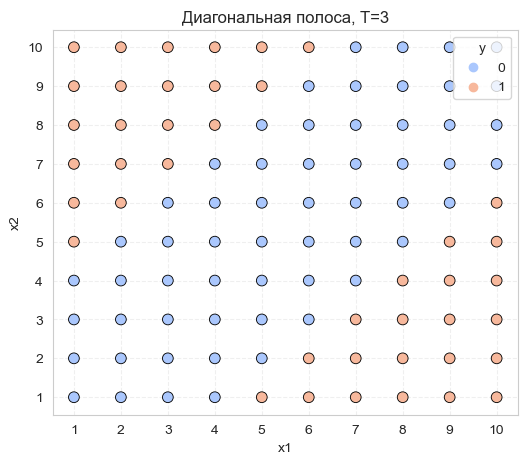

L2 (Euclidean) CV accuracy: 0.87 ± 0.0245
L1 (Manhattan) CV accuracy: 0.86 ± 0.0374


In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Сетка 1..10 x 1..10
x1 = np.repeat(np.arange(1, 11), 10)
x2 = np.tile(np.arange(1, 11), 10)
df = pd.DataFrame({'x1': x1, 'x2': x2})

# Диагональная полоса: класс 0, если |x1 - x2| <= T
T = 3  # ширина полосы; можно менять для баланса
diff = np.abs(df['x1'] - df['x2'])
df['y'] = (diff > T).astype(int)

print(df['y'].value_counts())

# Визуализация
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='coolwarm', edgecolor='k', s=60)
plt.xticks(range(1, 11))
plt.yticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.3)
plt.title(f'Диагональная полоса, T={T}')
plt.show()

X = df[['x1', 'x2']].values
y = df['y'].values

k = 5
knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=5, scoring='accuracy')
cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=5, scoring='accuracy')

print('L2 (Euclidean) CV accuracy:', round(cv_scores_l2.mean(), 4), '±', round(cv_scores_l2.std(), 4))
print('L1 (Manhattan) CV accuracy:', round(cv_scores_l1.mean(), 4), '±', round(cv_scores_l1.std(), 4))


Баланс классов:
1    56
0    44
Name: y, dtype: int64


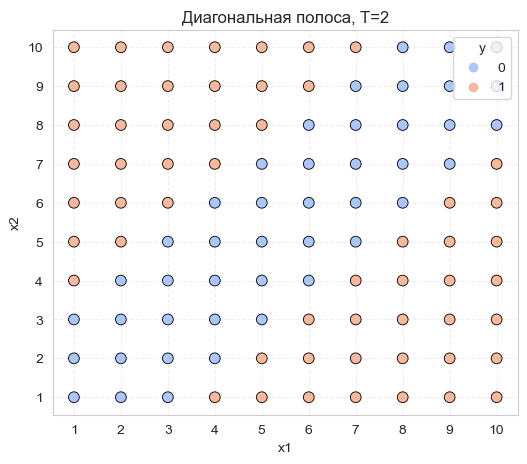

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1         0.84      0.0663         0.84      0.0663
1  3         0.90      0.0775         0.89      0.0700
2  5         0.92      0.0872         0.86      0.0663
3  7         0.94      0.0800         0.93      0.0781
4  9         0.91      0.0700         0.90      0.0775


In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Сетка 1..10 x 1..10
x1 = np.repeat(np.arange(1, 11), 10)
x2 = np.tile(np.arange(1, 11), 10)
df = pd.DataFrame({'x1': x1, 'x2': x2})

# Диагональная полоса: класс 0, если |x1 - x2| <= T
T = 2  # ширина полосы
diff = np.abs(df['x1'] - df['x2'])
df['y'] = (diff > T).astype(int)

print("Баланс классов:")
print(df['y'].value_counts())

# Визуализация
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='coolwarm', edgecolor='k', s=60)
plt.xticks(range(1, 11))
plt.yticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.3)
plt.title(f'Диагональная полоса, T={T}')
plt.show()

X = df[['x1', 'x2']].values
y = df['y'].values

k_vals = [1, 3, 5, 7, 9]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


0    200
1    200
Name: y, dtype: int64


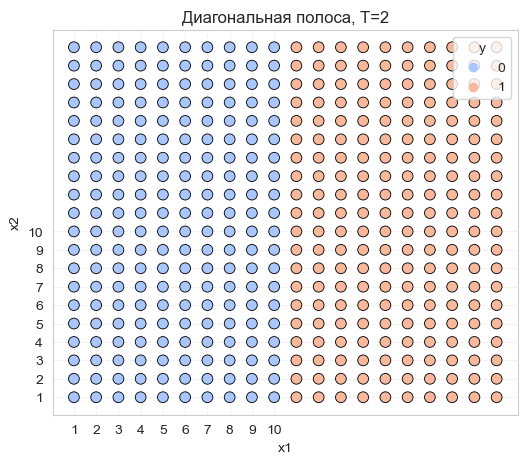

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1         0.95      0.1500         0.95        0.15
1  3         0.95      0.1500         0.95        0.15
2  5         0.95      0.1500         0.95        0.15
3  7         0.95      0.1204         0.95        0.15
4  9         0.95      0.1500         0.95        0.15


In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Сетка 1..20 x 1..20
x1 = np.repeat(np.arange(1, 21), 20)
x2 = np.tile(np.arange(1, 21), 20)
df = pd.DataFrame({'x1': x1, 'x2': x2})

# Осевая граница: класс 0, если x1 <= 10
df['y'] = (df['x1'] > 10).astype(int)

print(df['y'].value_counts())

X = df[['x1', 'x2']].values
y = df['y'].values

# Визуализация
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='coolwarm', edgecolor='k', s=60)
plt.xticks(range(1, 11))
plt.yticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.3)
plt.title(f'Диагональная полоса, T={T}')
plt.show()

k_vals = [1, 3, 5, 7, 9]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


Баланс классов:
0    200
1    200
Name: y, dtype: int64


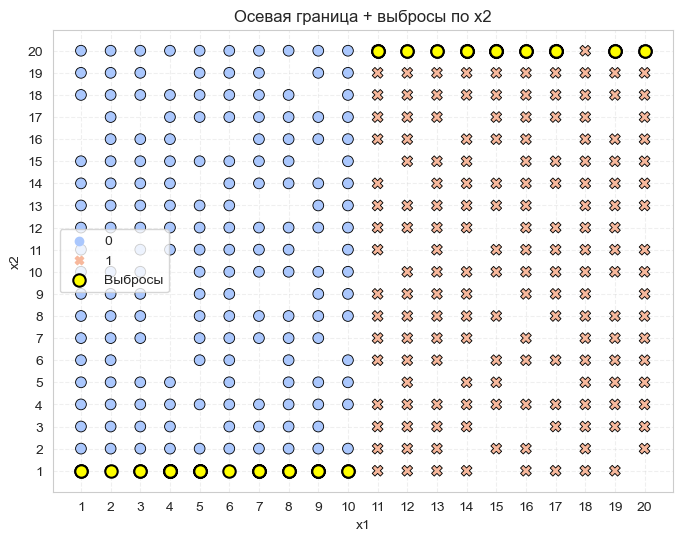

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1       0.9475      0.1344       0.9475      0.1344
1  3       0.9550      0.1122       0.9550      0.1122
2  5       0.9550      0.0927       0.9600      0.0917
3  7       0.9575      0.0852       0.9525      0.0952
4  9       0.9575      0.0895       0.9500      0.1055


In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(42)

# Сетка 1..20 x 1..20
x1_grid = np.repeat(np.arange(1, 21), 20)
x2_grid = np.tile(np.arange(1, 21), 20)
df = pd.DataFrame({'x1': x1_grid, 'x2': x2_grid})

# Осевая граница: x1 <= 10 -> класс 0, иначе 1
df['y'] = (df['x1'] > 10).astype(int)

# Добавим выбросы: в каждой полуплоскости часть точек имеет экстремальный x2
outlier_frac = 0.15  # 15% точек станут выбросами
n_points = len(df)
n_outliers = int(n_points * outlier_frac)

# Индексы для выбросов в классе 0 (x1 <= 10) и классе 1 (x1 > 10)
idx_class0 = df[df['y'] == 0].index
idx_class1 = df[df['y'] == 1].index

n_out0 = int(len(idx_class0) * outlier_frac)
n_out1 = int(len(idx_class1) * outlier_frac)

idx_out0 = np.random.choice(idx_class0, n_out0, replace=False)
idx_out1 = np.random.choice(idx_class1, n_out1, replace=False)

# Выбросы: экстремальные значения x2 (1 или 20), чтобы «ломать» L2
df.loc[idx_out0, 'x2'] = 1          # в классе 0 делаем x2 = 1
df.loc[idx_out1, 'x2'] = 20         # в классе 1 делаем x2 = 20

print("Баланс классов:")
print(df['y'].value_counts())

# Визуализация: цвет — класс, форма/цвет — выбросы
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', style='y', palette='coolwarm', edgecolor='k', s=60)
# подсветим выбросы отдельно
outliers = df.loc[np.concatenate([idx_out0, idx_out1])]
sns.scatterplot(data=outliers, x='x1', y='x2', color='yellow', edgecolor='black', s=80, linewidth=1.5, label='Выбросы')
plt.xticks(range(1, 21))
plt.yticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.3)
plt.title('Осевая граница + выбросы по x2')
plt.legend()
plt.show()

X = df[['x1', 'x2']].values
y = df['y'].values

k_vals = [1, 3, 5, 7, 9]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def generate_diagonal_density(n=50, density=200, noise=0.1):
    """
    Генератор датасета с точечными массами вдоль диагоналей.

    Вдоль главной диагонали (x=y) — плотное скопление класса 0.
    Вдоль побочной диагонали (x+y=n+1) — плотное скопление класса 1.
    Остальное пространство — равномерный шум.

    Ключевая идея: в некоторых клетках лежит МНОГО объектов.
    """
    np.random.seed(42)

    xs = []
    ys = []
    classes = []

    # Плотные скопления вдоль диагоналей
    for i in range(1, n+1):
        # Главная диагональ: x = y
        for _ in range(density):
            # Добавляем небольшой шум, чтобы точки не были строго на линии
            x = i + np.random.normal(0, 0.1)
            y = i + np.random.normal(0, 0.1)
            xs.append(x)
            ys.append(y)
            classes.append(0)

        # Побочная диагональ: x + y = n + 1
        for _ in range(density):
            x = i + np.random.normal(0, 0.1)
            y = (n + 1 - i) + np.random.normal(0, 0.1)
            xs.append(x)
            ys.append(y)
            classes.append(1)

    # Равномерный шум по всей плоскости
    n_noise = int(n * n * noise)
    for _ in range(n_noise):
        x = np.random.uniform(1, n+1)
        y = np.random.uniform(1, n+1)
        cls = np.random.choice([0, 1])
        xs.append(x)
        ys.append(y)
        classes.append(cls)

    df = pd.DataFrame({'x': xs, 'y': ys, 'class': classes})
    return df

# Генерация данных
df = generate_diagonal_density(n=50, density=200, noise=0.1)
print(f"Всего точек: {len(df)}")
print(f"Класс 0: {(df['class'] == 0).sum()}, Класс 1: {(df['class'] == 1).sum()}")

# Разделение на train/test
X = df[['x', 'y']].values
y = df['class'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Эксперимент: меняем метрику
for metric in ['euclidean', 'manhattan']:
    for k in [1, 3, 5]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, knn.predict(X_train))
        test_acc = accuracy_score(y_test, knn.predict(X_test))
        print(f"{metric}, k={k}: train={train_acc:.4f}, test={test_acc:.4f}")


Всего точек: 20250
Класс 0: 10132, Класс 1: 10118
euclidean, k=1: train=1.0000, test=0.9933
euclidean, k=3: train=0.9968, test=0.9933
euclidean, k=5: train=0.9956, test=0.9934
manhattan, k=1: train=1.0000, test=0.9926
manhattan, k=3: train=0.9970, test=0.9926
manhattan, k=5: train=0.9956, test=0.9931


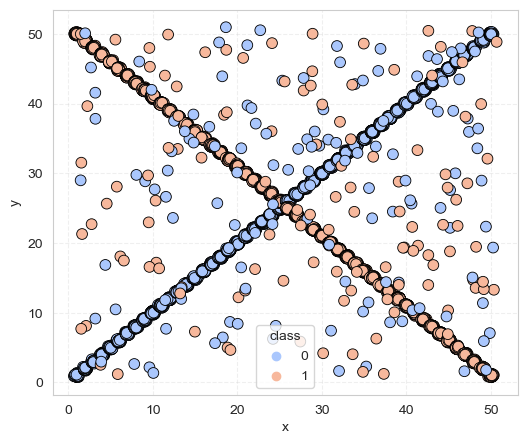

In [62]:
# Визуализация
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='x', y='y', hue='class', palette='coolwarm', edgecolor='k', s=60)
# plt.xticks(range(1, 11))
# plt.yticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.3)
# plt.title(f'Диагональная полоса, T={T}')
plt.show()

Баланс классов (без учёта редких):
0    221
1    219
dtype: int64


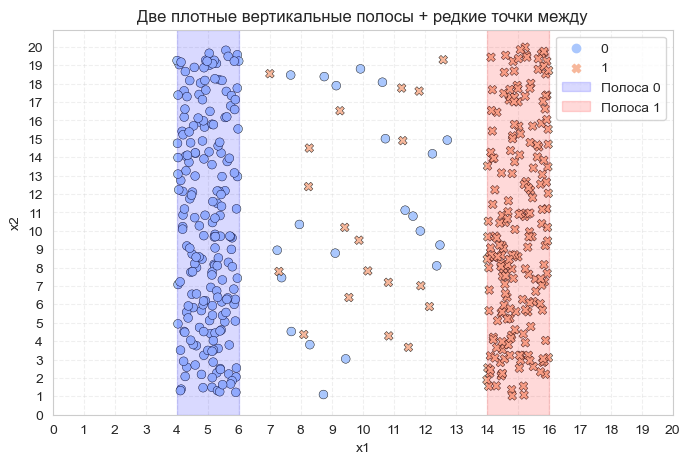

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1       0.9591      0.1227       0.9591      0.1227
1  3       0.9591      0.1227       0.9591      0.1227
2  5       0.9591      0.1227       0.9591      0.1227
3  7       0.9591      0.1227       0.9591      0.1227
4  9       0.9591      0.1227       0.9591      0.1227


In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(0)

# Полоса 1 (класс 0): x1 в [4,6], x2 равномерные 1..20
x1_0 = np.random.uniform(4, 6, size=200)
x2_0 = np.random.uniform(1, 20, size=200)
y_0 = np.zeros_like(x1_0, dtype=int)

# Полоса 2 (класс 1): x1 в [14,16], x2 равномерные 1..20
x1_1 = np.random.uniform(14, 16, size=200)
x2_1 = np.random.uniform(1, 20, size=200)
y_1 = np.ones_like(x1_1, dtype=int)

# Редкие точки между полосами (x1 в [7,13]) — они не принадлежат ни одному классу явно,
# но будут мешать L2 из-за своей «редкости» и разброса по x2
n_sparse = 40
x1_s = np.random.uniform(7, 13, size=n_sparse)
x2_s = np.random.uniform(1, 20, size=n_sparse)
# Присвоим им метки произвольно, но так, чтобы они не создавали плотную группу
y_s = np.random.choice([0, 1], size=n_sparse)  # не важно, главное — низкая плотность

X = np.vstack([
    np.column_stack([x1_0, x2_0]),
    np.column_stack([x1_1, x2_1]),
    np.column_stack([x1_s, x2_s])
])
y = np.concatenate([y_0, y_1, y_s])

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

print("Баланс классов (без учёта редких):")
print(pd.Series(y).value_counts())

# Визуализация
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', style='y', palette='coolwarm', s=40, edgecolor='k', linewidth=0.3)
plt.axvspan(4, 6, color='blue', alpha=0.15, label='Полоса 0')
plt.axvspan(14, 16, color='red', alpha=0.15, label='Полоса 1')
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 21, 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.title('Две плотные вертикальные полосы + редкие точки между')
plt.legend()
plt.show()

k_vals = [1, 3, 5, 7, 9]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


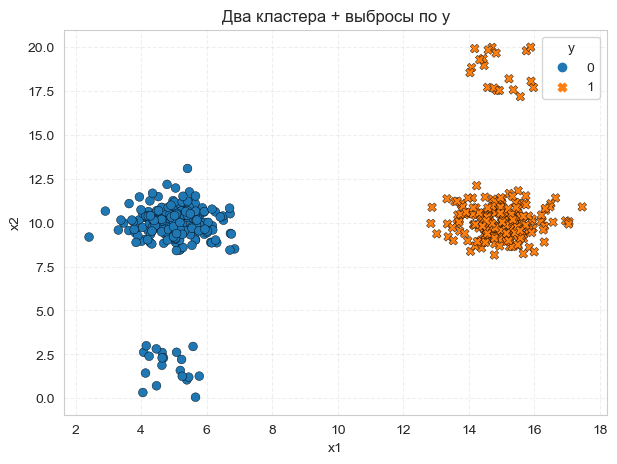

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1          1.0         0.0          1.0         0.0
1  3          1.0         0.0          1.0         0.0
2  5          1.0         0.0          1.0         0.0


In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(42)

# Два плотных кластера
n_cluster = 200
X0 = np.random.normal(loc=[5, 10], scale=[0.8, 0.8], size=(n_cluster, 2))
X1 = np.random.normal(loc=[15, 10], scale=[0.8, 0.8], size=(n_cluster, 2))

# Выбросы: по 20 точек, сильно сдвинутых по y
n_out = 20
out0 = np.column_stack([
    np.random.uniform(4, 6, size=n_out),
    np.random.uniform(0, 3, size=n_out)   # сильно вниз
])
out1 = np.column_stack([
    np.random.uniform(14, 16, size=n_out),
    np.random.uniform(17, 20, size=n_out) # сильно вверх
])

X = np.vstack([X0, X1, out0, out1])
y = np.array([0]*n_cluster + [1]*n_cluster + [0]*n_out + [1]*n_out)

df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', style='y', s=40, edgecolor='k', linewidth=0.3)
plt.title('Два кластера + выбросы по y')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

k_vals = [1, 3, 5]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


Баланс классов:
0    105
1    105
Name: y, dtype: int64


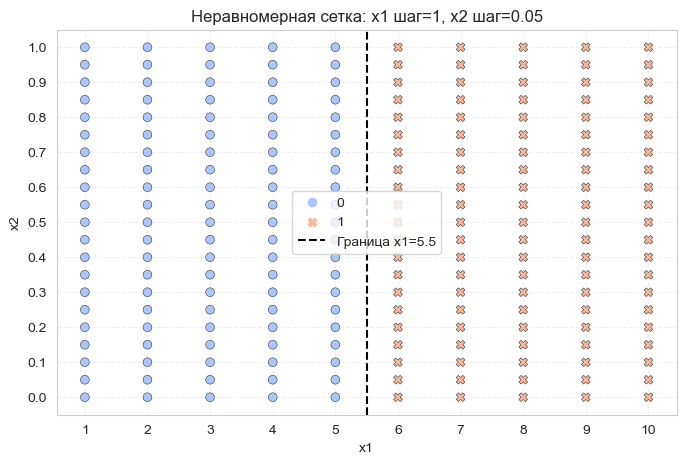

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1          1.0         0.0          1.0         0.0
1  3          1.0         0.0          1.0         0.0
2  5          1.0         0.0          1.0         0.0
3  7          1.0         0.0          1.0         0.0
4  9          1.0         0.0          1.0         0.0


In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(42)

# Ось x1: целые 1..10 (шаг 1)
x1_vals = np.arange(1, 11)
# Ось x2: шаг 0.05 от 0 до 1 (всего 21 значение)
x2_vals = np.linspace(0, 1, 21)

x1 = np.repeat(x1_vals, len(x2_vals))
x2 = np.tile(x2_vals, len(x1_vals))

df = pd.DataFrame({'x1': x1, 'x2': x2})

# Разделим по x1: если x1 <= 5 -> класс 0, иначе 1
df['y'] = (df['x1'] > 5).astype(int)

print("Баланс классов:")
print(df['y'].value_counts())

# Визуализация (важно: разный масштаб осей!)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', style='y', palette='coolwarm', s=40, edgecolor='k', linewidth=0.3)
plt.axvline(5.5, color='black', linestyle='--', linewidth=1.5, label='Граница x1=5.5')
plt.xticks(x1_vals)
plt.yticks(np.round(np.linspace(0, 1, 11), 2))
plt.grid(True, linestyle='--', alpha=0.3)
plt.title('Неравномерная сетка: x1 шаг=1, x2 шаг=0.05')
plt.legend()
plt.show()

X = df[['x1', 'x2']].values
y = df['y'].values

k_vals = [1, 3, 5, 7, 9]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


Баланс классов:
0    150
1    150
Name: y, dtype: int64


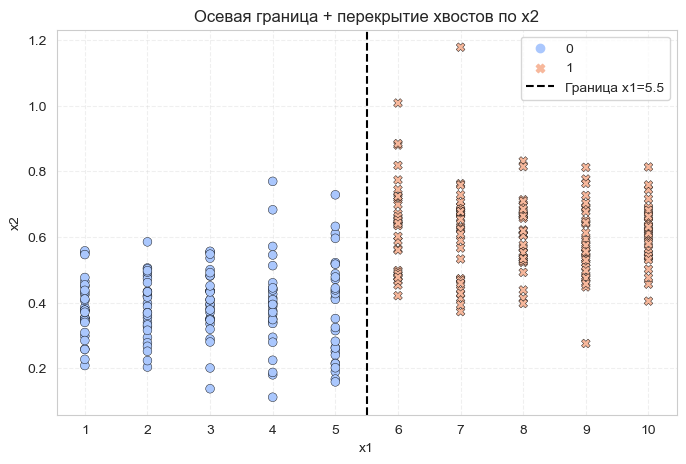

   k  acc_l2_mean  acc_l2_std  acc_l1_mean  acc_l1_std
0  1          1.0         0.0          1.0         0.0
1  3          1.0         0.0          1.0         0.0
2  5          1.0         0.0          1.0         0.0
3  7          1.0         0.0          1.0         0.0
4  9          1.0         0.0          1.0         0.0


In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

np.random.seed(42)

n_per_x1 = 30  # сколько точек на каждое значение x1
x1_vals = np.arange(1, 11)

data = []
labels = []

for x1 in x1_vals:
    # x2: нормальное распределение, среднее зависит от x1, чтобы создать перекрытие на границе
    # Чем ближе к границе (x1=5/6), тем больше перекрытие
    if x1 <= 5:
        mu_x2 = 0.4
    else:
        mu_x2 = 0.6
    
    # Добавляем шум: чем ближе к границе, тем больше дисперсия
    sigma_x2 = 0.15 if 4 <= x1 <= 7 else 0.1
    
    x2_samples = np.random.normal(loc=mu_x2, scale=sigma_x2, size=n_per_x1)
    y_samples = (x1 > 5).astype(int)
    
    for x2 in x2_samples:
        data.append([x1, x2])
        labels.append(y_samples)

df = pd.DataFrame(data, columns=['x1', 'x2'])
df['y'] = labels

print("Баланс классов:")
print(df['y'].value_counts())

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='x1', y='x2', hue='y', style='y', palette='coolwarm', s=40, edgecolor='k', linewidth=0.3)
plt.axvline(5.5, color='black', linestyle='--', linewidth=1.5, label='Граница x1=5.5')
plt.xticks(x1_vals)
plt.grid(True, linestyle='--', alpha=0.3)
plt.title('Осевая граница + перекрытие хвостов по x2')
plt.legend()
plt.show()

X = df[['x1', 'x2']].values
y = df['y'].values

k_vals = [1, 3, 5, 7, 9]
results = []

for k in k_vals:
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    cv_scores_l2 = cross_val_score(knn_l2, X, y, cv=10, scoring='accuracy')
    cv_scores_l1 = cross_val_score(knn_l1, X, y, cv=10, scoring='accuracy')

    results.append({
        'k': k,
        'acc_l2_mean': cv_scores_l2.mean(),
        'acc_l2_std': cv_scores_l2.std(),
        'acc_l1_mean': cv_scores_l1.mean(),
        'acc_l1_std': cv_scores_l1.std(),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4))


In [68]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

def generate_categorical_data(n_samples=2000, n_categories=50, noise=0.3, random_state=42):
    """
    Генератор датасета с двумя категориальными признаками.

    Ключевая идея:
    - Признак X (color) — ДЕЙСТВИТЕЛЬНО влияет на таргет.
      Чем больше индекс категории, тем выше вероятность класса 1.
    - Признак Y (size) — ЧИСТЫЙ ШУМ. Не влияет на таргет.

    Категории — это дискретные метки 0..49.
    """
    np.random.seed(random_state)

    # Генерируем категории
    X_cat1 = np.random.randint(0, n_categories, size=n_samples)  # color
    X_cat2 = np.random.randint(0, n_categories, size=n_samples)  # size (шум)

    # Таргет зависит от X_cat1 с некоторой вероятностью
    # Чем выше категория, тем выше P(class=1)
    prob_class1 = 0.1 + 0.8 * (X_cat1 / (n_categories - 1))  # от 0.1 до 0.9

    # Добавляем шум: часть объектов получает случайный таргет
    random_mask = np.random.random(n_samples) < noise
    y = (np.random.random(n_samples) < prob_class1).astype(int)

    # Если объект в шумовой маске — таргет становится случайным (50/50)
    random_y = np.random.randint(0, 2, size=n_samples)
    y = np.where(random_mask, random_y, y)

    # One Hot Encoding
    df = pd.DataFrame({'color': X_cat1, 'size': X_cat2, 'target': y})

    return df

# Генерация данных
df = generate_categorical_data(n_samples=2000, n_categories=50, noise=0.3)
print(f"Всего объектов: {len(df)}")
print(f"Класс 0: {(df['target'] == 0).sum()}, Класс 1: {(df['target'] == 1).sum()}")

# One Hot Encoding
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(df[['color', 'size']])
y = df['target'].values

print(f"Размерность после OHE: {X.shape[1]}")
print(f"Плотность (среднее число единиц): {X.sum(axis=1).mean():.2f}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Классификаторы
for metric in ['euclidean', 'manhattan']:
    for k in [1, 3, 5, 10]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        knn.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, knn.predict(X_train))
        test_acc = accuracy_score(y_test, knn.predict(X_test))
        print(f"{metric}, k={k}: train={train_acc:.4f}, test={test_acc:.4f}")


Всего объектов: 2000
Класс 0: 1004, Класс 1: 996
Размерность после OHE: 100
Плотность (среднее число единиц): 2.00
euclidean, k=1: train=0.8993, test=0.5333
euclidean, k=3: train=0.9064, test=0.5500
euclidean, k=5: train=0.9071, test=0.5550
euclidean, k=10: train=0.9071, test=0.5683
manhattan, k=1: train=0.8993, test=0.5333
manhattan, k=3: train=0.9064, test=0.5500
manhattan, k=5: train=0.9071, test=0.5550
manhattan, k=10: train=0.9071, test=0.5683


In [69]:
df

,color,size,target
0,38,2,0
1,28,5,0
2,14,8,1
3,42,5,1
4,7,8,0
...,...,...,...
1995,41,40,0
1996,43,29,1
1997,48,12,1
1998,39,20,0


In [72]:
X.shape

(2000, 100)

In [75]:
def generate_asymmetric_features(n=2000, noise=0.3):
    # Признак 1: сильный, диапазон 0-100
    x1 = np.random.uniform(0, 100, n)
    # Признак 2: шум, диапазон 0-2
    x2 = np.random.uniform(0, 2, n)
    # Таргет зависит от x1
    prob = 1 / (1 + np.exp(-(x1 - 50) / 10))
    y = (np.random.random(n) < prob).astype(int)
    return np.column_stack([x1, x2]), y
X, y = generate_asymmetric_features(n=2000, noise=0.3)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Классификаторы
for metric in ['euclidean', 'manhattan']:
    print('')
    for k in [1, 3, 5, 10]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        knn.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, knn.predict(X_train))
        test_acc = accuracy_score(y_test, knn.predict(X_test))
        print(f"{metric}, k={k}: train={train_acc:.4f}, test={test_acc:.4f}")



euclidean, k=1: train=1.0000, test=0.7767
euclidean, k=3: train=1.0000, test=0.8017
euclidean, k=5: train=1.0000, test=0.8167
euclidean, k=10: train=1.0000, test=0.8450

manhattan, k=1: train=1.0000, test=0.7883
manhattan, k=3: train=1.0000, test=0.8017
manhattan, k=5: train=1.0000, test=0.8200
manhattan, k=10: train=1.0000, test=0.8417


In [76]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

def generate_needle_target(n_samples=2000, 
                           n_categories=50,
                           signal_mode='single',  # 'single' | 'interaction'
                           signal_cat1='A', 
                           signal_cat2='B',
                           noise_level=0.0,
                           class_balance=0.5,
                           random_state=42):
    """
    Генератор данных с "игольным" таргетом.

    Идея: таргет зависит от НЕСКОЛЬКИХ конкретных категорий.
    Всё остальное — шум.

    Параметры:
    ----------
    n_samples : int
        Число объектов.
    n_categories : int
        Число категорий в каждом признаке (будут буквы A, B, C, ...).
    signal_mode : str
        'single' — таргет = 1, если color == signal_cat1.
        'interaction' — таргет = 1, если color == signal_cat1 И size == signal_cat2.
    signal_cat1, signal_cat2 : str
        Категории, которые кодируют класс 1.
    noise_level : float
        Доля объектов, у которых таргет инвертирован (шум).
    class_balance : float
        Доля класса 1 в выборке (примерно).
    """
    np.random.seed(random_state)

    # Список категорий: A, B, C, ... (до 26*26 категорий при необходимости)
    alphabet = []
    for i in range(26):
        for j in range(26):
            alphabet.append(chr(65 + i) + (chr(97 + j) if j > 0 else ''))
    categories = alphabet[:n_categories]

    # Генерируем случайные категории
    x1 = np.random.choice(categories, size=n_samples)  # color
    x2 = np.random.choice(categories, size=n_samples)  # size

    # 1. Формируем "истинный" таргет (до шума)
    if signal_mode == 'single':
        # Класс 1: color == signal_cat1
        y_true = (x1 == signal_cat1).astype(int)
    elif signal_mode == 'interaction':
        # Класс 1: color == signal_cat1 AND size == signal_cat2
        y_true = ((x1 == signal_cat1) & (x2 == signal_cat2)).astype(int)
    else:
        raise ValueError("signal_mode должен быть 'single' или 'interaction'")

    # Смотрим, сколько у нас объектов в классе 1
    n_pos = y_true.sum()
    n_neg = n_samples - n_pos

    print(f"Истинное распределение (до шума):")
    print(f"  Класс 0: {n_neg} ({n_neg/n_samples*100:.1f}%)")
    print(f"  Класс 1: {n_pos} ({n_pos/n_samples*100:.1f}%)")

    # 2. Добавляем шум: инвертируем таргет у random_mask
    if noise_level > 0:
        n_noise = int(n_samples * noise_level)
        noise_idx = np.random.choice(n_samples, size=n_noise, replace=False)
        y = y_true.copy()
        y[noise_idx] = 1 - y[noise_idx]
        print(f"  Шум: {n_noise} объектов инвертировано ({noise_level*100:.1f}%)")
    else:
        y = y_true.copy()

    # Сохраняем в DataFrame
    df = pd.DataFrame({
        'color': x1,
        'size': x2,
        'target': y
    })

    return df

# ============================================================
# Демонстрация: режим 'single'
# ============================================================
print("=" * 60)
print("РЕЖИМ: ОДНА СИГНАЛЬНАЯ КАТЕГОРИЯ")
print("=" * 60)

df = generate_needle_target(
    n_samples=2000,
    n_categories=50,
    signal_mode='single',
    signal_cat1='A',      # Только 'A' в color → класс 1
    noise_level=0.0,
    random_state=42
)
print(df.groupby('target').size())

# One Hot Encoding
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(df[['color', 'size']])
y = df['target'].values

print(f"\nРазмерность после OHE: {X.shape[1]}")
print(f"Плотность (среднее число единиц): {X.sum(axis=1).mean():.2f}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Сравнение метрик
print("\nРезультаты:")
for metric in ['euclidean', 'manhattan']:
    for k in [5, 10, 20]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        knn.fit(X_train, y_train)
        test_acc = accuracy_score(y_test, knn.predict(X_test))
        print(f"  {metric}, k={k}: test_accuracy={test_acc:.4f}")


РЕЖИМ: ОДНА СИГНАЛЬНАЯ КАТЕГОРИЯ
Истинное распределение (до шума):
  Класс 0: 1960 (98.0%)
  Класс 1: 40 (2.0%)
target
0    1960
1      40
dtype: int64

Размерность после OHE: 100
Плотность (среднее число единиц): 2.00

Результаты:
  euclidean, k=5: test_accuracy=0.9983
  euclidean, k=10: test_accuracy=0.9900
  euclidean, k=20: test_accuracy=0.9917
  manhattan, k=5: test_accuracy=0.9983
  manhattan, k=10: test_accuracy=0.9900
  manhattan, k=20: test_accuracy=0.9917


In [77]:
def generate_needle_target_balanced(n_samples=2000,
                                    n_categories=50,
                                    signal_mode='single',
                                    signal_cat1='A',
                                    signal_cat2='B',
                                    noise_level=0.0,
                                    class_balance=0.5,
                                    random_state=42):
    """
    Тот же генератор, но теперь мы ДОБАВЛЯЕМ редкие классы,
    чтобы они были равномерно распределены.
    """
    np.random.seed(random_state)

    alphabet = []
    for i in range(26):
        for j in range(26):
            alphabet.append(chr(65 + i) + (chr(97 + j) if j > 0 else ''))
    categories = alphabet[:n_categories]

    # Сгенерируем ОБЪЕДИНЁННЫЕ данные
    # Чтобы классы были сбалансированы, мы генерируем ПОРОВНУ:
    n_per_class = n_samples // 2

    if signal_mode == 'single':
        # Класс 1: color = signal_cat1
        x1_pos = np.full(n_per_class, signal_cat1)  # все - signal_cat1
        x1_neg = np.random.choice([c for c in categories if c != signal_cat1], 
                                   size=n_per_class)
        x2_pos = np.random.choice(categories, size=n_per_class)
        x2_neg = np.random.choice(categories, size=n_per_class)

        y = np.array([1]*n_per_class + [0]*n_per_class)
        x1 = np.concatenate([x1_pos, x1_neg])
        x2 = np.concatenate([x2_pos, x2_neg])

    elif signal_mode == 'interaction':
        # Класс 1: color = signal_cat1 И size = signal_cat2
        x1_pos = np.full(n_per_class, signal_cat1)
        x2_pos = np.full(n_per_class, signal_cat2)
        # Класс 0: все остальные комбинации
        # Будем выбирать так, чтобы в классе 0 НЕ было этой пары
        all_combinations = [(c1, c2) 
                            for c1 in categories 
                            for c2 in categories 
                            if not (c1 == signal_cat1 and c2 == signal_cat2)]
        neg_combinations = np.random.choice(len(all_combinations), n_per_class)
        x1_neg = [all_combinations[i][0] for i in neg_combinations]
        x2_neg = [all_combinations[i][1] for i in neg_combinations]

        y = np.array([1]*n_per_class + [0]*n_per_class)
        x1 = np.concatenate([x1_pos, x1_neg])
        x2 = np.concatenate([x2_pos, x2_neg])

    # Перемешаем
    idx = np.random.permutation(n_samples)
    x1, x2, y = x1[idx], x2[idx], y[idx]

    # Добавляем шум
    if noise_level > 0:
        n_noise = int(n_samples * noise_level)
        noise_idx = np.random.choice(n_samples, size=n_noise, replace=False)
        y[noise_idx] = 1 - y[noise_idx]

    df = pd.DataFrame({'color': x1, 'size': x2, 'target': y})
    return df


In [78]:
df = generate_needle_target_balanced(n_samples=2000,
                                    n_categories=50,
                                    signal_mode='single',
                                    signal_cat1='A',
                                    signal_cat2='B',
                                    noise_level=0.0,
                                    class_balance=0.5,
                                    random_state=42)
df

,color,size,target
0,Bg,Bg,0
1,A,Ax,1
2,A,Ak,1
3,A,Bt,1
4,Bu,Ad,0
...,...,...,...
1995,A,Az,1
1996,A,An,1
1997,Bt,Ax,0
1998,Bh,As,0


In [90]:
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(df[['color', 'size']])
y = df['target'].values

print(f"\nРазмерность после OHE: {X.shape[1]}")
print(f"Плотность (среднее число единиц): {X.sum(axis=1).mean():.2f}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Сравнение метрик
print("\nРезультаты:")
for metric in ['euclidean', 'manhattan']:
    print('')
    for k in [5, 10, 20, 100, 200]:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        knn.fit(X_train, y_train)
        test_acc = accuracy_score(y_test, knn.predict(X_test))
        print(f"  {metric}, k={k}: test_accuracy={test_acc:.4f}")



Размерность после OHE: 100
Плотность (среднее число единиц): 2.00

Результаты:

  euclidean, k=5: test_accuracy=0.8900
  euclidean, k=10: test_accuracy=0.9667
  euclidean, k=20: test_accuracy=0.9900
  euclidean, k=100: test_accuracy=0.9983
  euclidean, k=200: test_accuracy=1.0000

  manhattan, k=5: test_accuracy=0.8900
  manhattan, k=10: test_accuracy=0.9667
  manhattan, k=20: test_accuracy=0.9917
  manhattan, k=100: test_accuracy=0.9983
  manhattan, k=200: test_accuracy=1.0000


In [89]:
mask = df['color'] == 'A'

df.loc[~mask].sum()

color     BgBuBnAqAmBeBrAvBlBxBmBfBkAoAeAhBiBxAiAfBkAxAe...
size      BgAdAoAlArAvAtBqBbAyBArBcAjBcAfBdBrBiAmBtAuAoA...
target                                                    0
dtype: object